## Cluster characteristics computation

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

def filter_veneto(df, shapefile_path, name_column='tipo_p'):
    """
    Filters the input DataFrame to only include points within the Veneto region,
    and adds a column with landscape name.

    Parameters:
    - df: pandas.DataFrame with 'lon' and 'lat' columns
    - shapefile_path: path to the Veneto shapefile (should be in EPSG:4326 or reprojected)
    - name_column: name of the column in shapefile for province/landscape (e.g., 'tipo_p')

    Returns:
    - filtered DataFrame with a new column (landscape) for the landscape info within the Veneto Region
    """
    # Load shapefile as GeoDataFrame
    veneto_gdf = gpd.read_file(shapefile_path)
    veneto_gdf = veneto_gdf.to_crs(epsg=4326)  # Ensure CRS is WGS84

    # Create GeoDataFrame from input df
    geometry = gpd.points_from_xy(df['lon'], df['lat'])
    df_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

    # Spatial join: match points to polygons
    joined = gpd.sjoin(df_gdf, veneto_gdf[[name_column, 'geometry']], how='inner', predicate='within')

    # Rename the joined name column to avoid confusion
    joined = joined.rename(columns={name_column: 'landscape'})

    return joined.drop(columns=['geometry','index_right'])



In [ ]:
# This is an example: takes as input the precipitation cluster file and crops it to Veneto
#filter_veneto(precipitation,'INPUT_data/boundaries/c1103018013_ricognizionepaesaggivenetoperimetri.shp')

In [ ]:
def total_extension(df,cluster_name,name):
    """
    Calculates the total extension (in days) of each cluster at each location (lon, lat),
    based on the number of days with a valid TOT_PREC_MASK value.

    Parameters:
    - df: DataFrame containing at least ['lon', 'lat', cluster_name, name]
    - cluster_name: str, name of the column representing the ID of the cluster/group (e.g., prec_clusters)
    - name: str, name of the column representing the variable of the cluster (e.g., TOT_PREC)

    Returns:
    - A DataFrame with [cluster_name, 'total_extension']
    """
    total_extension_df=df.groupby([cluster_name])[name].size().reset_index(name='total_extension')
    return(total_extension_df)

def duration(df, cluster_name, date_column='time'):
    """
    Calculates duration per cluster based on min and max date.

    Parameters:
    - df: DataFrame with at least [cluster_name, date_column]
    - cluster_name: str, column name identifying clusters (e.g., 'landscape')
    - date_column: str, name of the date column (default: 'date')

    Returns:
    - DataFrame with cluster_name, min_date, max_date, and duration (days)
    """
    # Ensure date column is datetime
    df[date_column] = pd.to_datetime(df[date_column])

    result = (
        df.groupby(cluster_name)[date_column]
          .agg(min_date='min', max_date='max')
          .reset_index()
    )
    
    result['duration'] = (result['max_date'] - result['min_date']).dt.days + 1
    
    return result

def spatial_extension(df, cluster_name):
    """
    Calculates the number of unique (lon, lat) cells involved in each cluster.

    Parameters:
    - df: DataFrame containing ['lon', 'lat', cluster_name]
    - cluster_name: str, column name representing the cluster ID

    Returns:
    - A DataFrame with [cluster_name, 'total_cells']
    """
    total_cells_df = (
        df.drop_duplicates(subset=['lon', 'lat', cluster_name])  # ensure unique spatial points per cluster
          .groupby(cluster_name)[['lon', 'lat']]
          .size()
          .reset_index(name='total_cells')
    )
    return total_cells_df

def mean_intensity_per_cluster(df, cluster_name, intensity_var):
    """
    Calculates the mean intensity of a given variable for each cluster.

    Parameters:
    - df: DataFrame containing at least [cluster_name, intensity_var]
    - cluster_name: str, name of the column representing the cluster ID
    - intensity_var: str, name of the column representing intensity (e.g., SPI_12)

    Returns:
    - A DataFrame with [cluster_name, 'mean_intensity']
    """
    mean_intensity_df = (
        df.groupby(cluster_name)[intensity_var]
        .mean()
        .reset_index(name='mean_intensity')
    )
    return mean_intensity_df

def max_intensity_per_cluster(df, cluster_name, intensity_var):
    """
    Calculates the max intensity of a given variable for each cluster.

    Parameters:
    - df: DataFrame containing at least [cluster_name, intensity_var]
    - cluster_name: str, name of the column representing the cluster ID
    - intensity_var: str, name of the column representing intensity (e.g., SPI_12)

    Returns:
    - A DataFrame with [cluster_name, 'mean_intensity']
    """
    if cluster_name=='drought_clusters':
        max_intensity_df = (
            df.groupby(cluster_name)[intensity_var]
            .min()
            .reset_index(name='mean_intensity')
        )
    else:
        max_intensity_df = (
                df.groupby(cluster_name)[intensity_var]
                .max()
                .reset_index(name='mean_intensity')
            )
    return max_intensity_df

def seasonality_per_cluster(df, cluster_name):
    """
    Calculates the dominant season for each cluster (i.e., the season with the majority of occurrences).

    Parameters:
    - df: DataFrame with at least ['time', cluster_name]
    - cluster_name: str, name of the column representing the cluster ID

    Returns:
    - A DataFrame with [cluster_name, 'seasonality']
    """
    # Extract month from time column
    df = df.copy()
    df['month'] = pd.to_datetime(df['time']).dt.month

    # Map months to seasons
    month_to_season = {
        12: 'winter', 1: 'winter', 2: 'winter',
        3: 'spring', 4: 'spring', 5: 'spring',
        6: 'summer', 7: 'summer', 8: 'summer',
        9: 'fall', 10: 'fall', 11: 'fall'
    }
    df['season'] = df['month'].map(month_to_season)

    # Get dominant season per cluster (mode of season values)
    seasonality_df = (
        df.groupby(cluster_name)['season']
        .agg(lambda x: x.mode().iloc[0])  # Use mode (most frequent)
        .reset_index(name='seasonality')
    )

    return seasonality_df

def landscape_per_cluster(df, cluster_name):
    """
    Calculates the dominant (most frequent) landscape type for each cluster.

    Parameters:
    - df: DataFrame with at least [cluster_name, 'landscape']
    - cluster_name: str, the column name representing the cluster ID

    Returns:
    - A DataFrame with [cluster_name, 'dominant_landscape']
    """
    df=filter_veneto(df,'boundaries/c1103018013_ricognizionepaesaggivenetoperimetri.shp')

    dominant_landscape_df = (
        df.groupby(cluster_name)['landscape']
        .agg(lambda x: x.mode().iloc[0])  # Use most frequent landscape
        .reset_index(name='dominant_landscape')
    )
    
    return dominant_landscape_df

    return seasonality_df

def compound_event_stats(df, cluster_name, hazard1, hazard2):
    """
    Calculates mean and max intensity for two hazards, and total extension for each cluster.

    Parameters:
    - df: DataFrame with at least [cluster_name, hazard1, hazard2]
    - cluster_name: str, column name of cluster ID
    - hazard1: str, first hazard intensity column (e.g., 'SPI_12')
    - hazard2: str, second hazard intensity column (e.g., 'TOT_PREC')

    Returns:
    - DataFrame with [cluster_name, mean/max of hazard1/2, total_extension]
    """

   # Get hazard names from cluster_name string
    try:
        name1, name2 = cluster_name.split('_')
    except ValueError:
        raise ValueError(f"Expected cluster_name to contain exactly one '_', got: {cluster_name}")

    is_drought = 'drought' in cluster_name.lower()

    grouped = df.groupby(cluster_name)

    result = grouped.agg(
        **{f'mean_{name1}': (hazard1, 'mean')},
        **{f'max_{name1}': (hazard1, lambda x: x.min() if is_drought else x.max())},
        **{f'mean_{name2}': (hazard2, 'mean')},
        **{f'max_{name2}': (hazard2, lambda x: x.min() if is_drought else x.max())},
        total_extension=(hazard1, 'count')
    ).reset_index()

    return result

import matplotlib.pyplot as plt

def plot_compound_event_stats(df, hazard1_label, hazard2_label, label_dict=None):
    """
    Scatter plot of mean intensities of two hazards.
    Point size proportional to total extension.

    Parameters:
    - df: DataFrame with columns like mean_{hazard1_label}, mean_{hazard2_label}, total_extension
    - hazard1_label: str, key for first hazard (used to find mean_{hazard1_label})
    - hazard2_label: str, key for second hazard (used to find mean_{hazard2_label})
    - label_dict: dict mapping hazard keys to axis labels (optional)
    """

    col1 = f"mean_{hazard1_label}"
    col2 = f"mean_{hazard2_label}"

    if col1 not in df.columns or col2 not in df.columns:
        raise ValueError(f"DataFrame must contain columns '{col1}' and '{col2}'")

    xlabel = label_dict.get(hazard1_label, hazard1_label) if label_dict else hazard1_label
    ylabel = label_dict.get(hazard2_label, hazard2_label) if label_dict else hazard2_label

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        df[col1], df[col2],
        s=df['total_extension'] * 2,
        alpha=0.7, edgecolors='black'
    )

    plt.xlabel(f'Mean Intensity: {xlabel}')
    plt.ylabel(f'Mean Intensity: {ylabel}')
    plt.title('Compound Events: Mean Intensities vs. Extension')

    # Invert axis if drought is involved
    if hazard1_label == 'drought':
        plt.gca().invert_xaxis()
    if hazard2_label == 'drought':
        plt.gca().invert_yaxis()

    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 3D single hazard plots

In [ ]:
def plot_3d_clusters_intensity(df, value_column,hazard, start_date=None, end_date=None, cmap="magma"):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    import matplotlib.colors as mcolors
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.dates as mdates
    """
    Plots a 3D scatter plot of longitude, latitude, and time, 
    with points colored according to the values in a given column.
    
    Parameters:
        df (pd.DataFrame): The dataframe containing 'lon', 'lat', 'time', and the specified value column.
        value_column (str): The column to use for coloring the points.
        start_date (str, optional): Start date in 'YYYY-MM-DD' format.
        end_date (str, optional): End date in 'YYYY-MM-DD' format.
        cmap (str, optional): Colormap to use (default is "viridis").
    """
    # Convert 'time' column to datetime
    df["time"] = pd.to_datetime(df["time"])
    df=df[df['new_clusters']!=-1]

    # Apply date filter if provided
    if start_date:
        df = df[df["time"] >= pd.to_datetime(start_date)]
    if end_date:
        df = df[df["time"] <= pd.to_datetime(end_date)]

    # Get min and max values for normalization
    vmin = df[value_column].min()
    vmax = df[value_column].max()

    # Define colormap
    
    if hazard!='Drought':
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap(cmap)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=0)
        cmap = plt.get_cmap(cmap+"_r")

    # Plot
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection="3d")

    # Scatter plot
    sc = ax.scatter(df["lon"], df["lat"], df["time"].map(mdates.date2num), 
                    c=df[value_column], cmap=cmap, norm=norm, alpha=0.7)

    # Labels and formatting
    ax.invert_xaxis()
    ax.set_xlabel("Longitude", labelpad=20)
    ax.invert_yaxis()
    ax.set_ylabel("Latitude", labelpad=20)
    #ax.set_zlabel("Time", labelpad=10)
    ax.set_title(f"3D Multi-Hazard clusters - {hazard}", pad=20)
    ax.view_init(elev=20, azim=60)

    # Format Z-axis to display real dates
    ax.zaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.zaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=6))
    plt.setp(ax.get_zticklabels(), rotation=15, ha="right")
    ax.tick_params(axis='z', pad=35)  # Add padding to the Z-axis tick labels
    ax.zaxis.labelpad = 10  # Add padding to the Z-axis label

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label(value_column)

    plt.xticks(rotation=45)
    plt.show()

def plot_3d_clusters(df, hazard,cluster_column='new_clusters',start_date=None, end_date=None):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    import matplotlib.colors as mcolors
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.dates as mdates
    """
    Plots a 3D scatter plot of longitude, latitude, and time, 
    with points colored according to the 'clusters' column.
    
    Parameters:
        df (pd.DataFrame): The dataframe containing 'lon', 'lat', 'time', and 'clusters'.
        start_date (str, optional): Start date in 'YYYY-MM-DD' format.
        end_date (str, optional): End date in 'YYYY-MM-DD' format.
    """
    # Convert 'time' column to datetime
    df["time"] = pd.to_datetime(df["time"])
    df=df[df['new_clusters']!=-1]

    # Apply date filter if provided
    if start_date:
        df = df[df["time"] >= pd.to_datetime(start_date)]
    if end_date:
        df = df[df["time"] <= pd.to_datetime(end_date)]

    # Define colors for clusters
    unique_clusters = df[cluster_column].unique()
    colors = plt.cm.get_cmap("tab10", len(unique_clusters))  # Get distinct colors
    cluster_color_map = {c: colors(i) for i, c in enumerate(unique_clusters)}

    # Plot
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection="3d")
    #ax = fig.add_axes([0.6, 0.3, 0.35, 0.35], projection='3d')

    # Scatter plot
    for cluster in unique_clusters:
        cluster_df = df[df[cluster_column] == cluster]
        ax.scatter(cluster_df["lon"], cluster_df["lat"], cluster_df["time"].map(mdates.date2num), 
                   color=cluster_color_map[cluster], label=f"Cluster {cluster}", alpha=0.4)

    # Labels and formatting
    ax.invert_xaxis()
    ax.set_xlabel("Longitude", labelpad=20)
    ax.invert_yaxis()
    ax.set_ylabel("Latitude", labelpad=20)
    #ax.set_zlabel("Time", labelpad=10)
    ax.set_title("3D Multi-Hazard Clustering - "+hazard, pad=20)
    #ax.set_title("3D Multi-Hazard Clustering")
    ax.view_init(elev=20, azim=60)

    
    # Format Z-axis to display real dates
    ax.zaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #ax.zaxis.set_major_locator(mdates.AutoDateLocator())
    ax.zaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=6))
    # Rotate Z-axis labels to prevent overlap
    #ax.zaxis.labelpad = 25
    plt.setp(ax.get_zticklabels(), rotation=15, ha="right")
    ax.tick_params(axis='z', pad=35)  # Add padding to the Z-axis tick labels
    ax.zaxis.labelpad = 10  # Add padding to the Z-axis label

    plt.xticks(rotation=45)
    ax.legend()
    plt.show()

In [ ]:
plot_3d_clusters(heatwave, 'Heatwaves',start_date="2018-01-01", end_date="2022-10-30")

In [ ]:
plot_3d_clusters_intensity(heatwave,'T_2M','Heatwaves',start_date="2018-01-01", end_date="2022-10-31",cmap='seismic')

## Predominant multi-hazard pair map

In [7]:
def plot_frequency_map(name_file, shapefile, scenario, outpath=None, point_size=3, use_log=False,name='Heat'):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import geopandas as gpd
    from matplotlib import colors
    '''This function plots single hazard frequency maps'''

    # Read Veneto borders (or region borders) and ensure WGS84
    gdf = gpd.read_file(shapefile).to_crs(epsg=4326)

    # Base map
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12.5, 9.6))
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)

    # Add borders
    gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, linestyle='-', transform=ccrs.PlateCarree())

    # Focus on NE Italy (same as your function)
    ax.set_extent([10.3, 13.3, 44.4, 47.1], crs=ccrs.PlateCarree())

    # Gridlines
    gridlines = ax.gridlines(draw_labels=True, linestyle='--')
    gridlines.top_labels = False
    gridlines.right_labels = False
    
    df=pd.read_csv('OUTPUT/'+name_file)
    df_freq=df.groupby(['lon','lat'])['date'].count().reset_index(name='frequency')
    
    # ----- Continuous color mapping -----
    vmin = float(np.nanmin(df_freq["frequency"]))
    vmax = float(np.nanmax(df_freq["frequency"]))

    if use_log:
        # Good when frequencies are very skewed
        norm = colors.LogNorm(vmin=max(vmin, 1), vmax=vmax)
    else:
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    

    sc = ax.scatter(
        df_freq["lon"], df_freq["lat"],
        c=df_freq["frequency"],
        cmap="Reds",
        norm=norm,
        s=point_size,
        transform=ccrs.PlateCarree()
    )

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
    cbar.set_label("Frequency (# event-days per pixel)")

    # Title
    plt.title(f"{name} Frequency by Location — {scenario}")

    # Save if requested
    if outpath is not None:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")

    plt.show()

'''This is an example:
plot_frequency_map(
    name_file='Historical_Heat.csv',
    shapefile="../Limiti/Regioni/c0104021_province.shp",
    scenario="Historical",
    outpath="../OUTPUT/prova.png",
    point_size=4,
    use_log=False,  # try True if the color is dominated by a few hotspots
    name='Heat'
)'''

'This is an example:\nplot_frequency_map(\n    name_file=\'Historical_Heat.csv\',\n    shapefile="../Limiti/Regioni/c0104021_province.shp",\n    scenario="Historical",\n    outpath="../OUTPUT/prova.png",\n    point_size=4,\n    use_log=False,  # try True if the color is dominated by a few hotspots\n    name=\'Heat\'\n)'

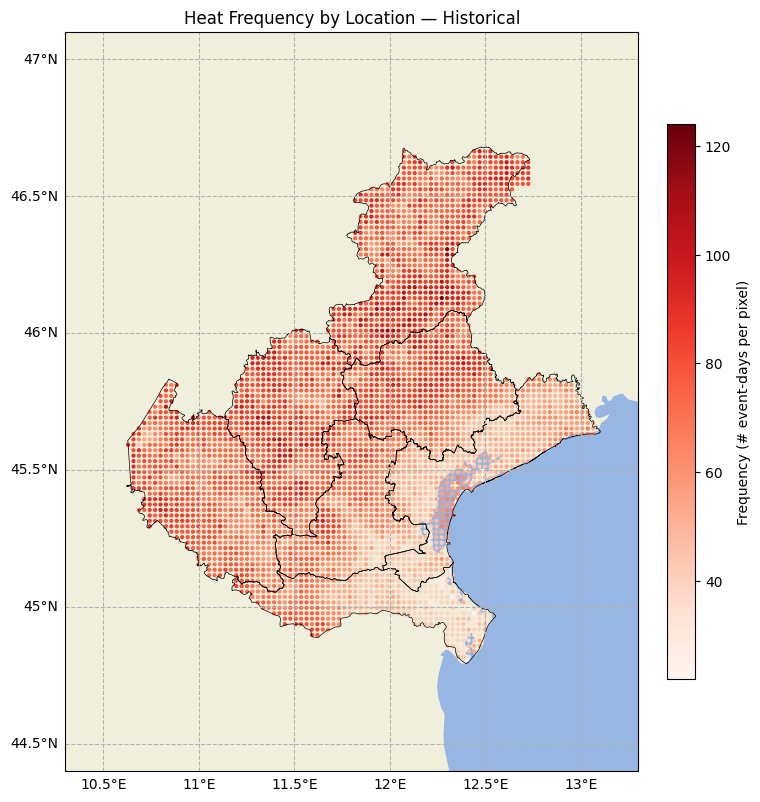

In [8]:
plot_frequency_map(
    name_file='Historical_Heat.csv',
    shapefile="Limiti/Regioni/c0104021_province.shp",
    scenario="Historical",
    outpath="OUTPUT/prova.png",
    point_size=4,
    use_log=False,  # try True if the color is dominated by a few hotspots
    name='Heat'
)

In [15]:
def plot_multi_hazards_compound(
    df,
    shapefile,
    scenario,
    clip_to_veneto=True,
    outpath=None,
    extent=(10.3, 13.3, 44.8, 46.9),
):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import geopandas as gpd
    from matplotlib.lines import Line2D
    import pandas as pd

    '''This function plots the predominant multi-hazard combination given a csv file of MH_combos'''

    # --- Colors (keep yours, but you may want to swap yellow later)
    class_colors = {
        "prec_wind": "navy",
        "prec_drought": "forestgreen",
        "prec_heat": "orchid",
        "drought_wind": "gold",
        "drought_heat": "crimson",
        "heat_wind": "orange",
        "prec_wind_heat": "sienna",
        "prec_wind_drought": "cyan",
        "prec_drought_heat": "ivory",
        "drought_wind_heat": "chartreuse",
        "prec_wind_heat_drought": "black"
    }

    # --- Read & prepare Veneto geometry
    gdf = gpd.read_file(shapefile).to_crs(epsg=4326)
    veneto_geom = gdf.dissolve().geometry.iloc[0]  # single polygon

    # --- Optionally clip points to Veneto
    plot_df = df.copy()
    # --- Fix "all-zero" rows wrongly assigned to a class (e.g., prec_wind)
    combo_cols = list(class_colors.keys())
    print(combo_cols)
    # ensure numeric (in case they are strings)
    plot_df[combo_cols] = plot_df[combo_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    #print(combo_cols)
    #print(plot_df[combo_cols])
    all_zero = plot_df[combo_cols].sum(axis=1) == 0
    print(all_zero.sum())
    plot_df.loc[all_zero, "class"] = "none"
    class_colors["none"]:"white"

    if clip_to_veneto:
        pts = gpd.GeoDataFrame(
            plot_df,
            geometry=gpd.points_from_xy(plot_df["lon"], plot_df["lat"]),
            crs="EPSG:4326",
        )
        pts = pts[pts.within(veneto_geom)]
        plot_df = pts.drop(columns="geometry")

    # --- Plot
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(11.5, 8.5))

    ax.set_extent(extent, crs=proj)

    # Subtle basemap
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
    ax.coastlines(resolution="10m", linewidth=0.6, color="0.4")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.5")

    # Veneto boundary (slightly thicker)
    gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.9, transform=proj, zorder=3)

    # Gridlines: subtle
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, color="0.6", alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    # Plot each class (rasterized helps when saving PDFs)
    for class_name, color in class_colors.items():
        sub = plot_df[plot_df["class"] == class_name]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["lon"], sub["lat"],
            c=color, s=3,
            linewidths=0,
            transform=proj,
            rasterized=True,
            zorder=2,
        )

    # Better legend (custom handles; more compact)
    handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=class_colors[k], markersize=6, label=k.replace("_", " + "))
        for k in class_colors.keys()
    ]
    ax.legend(
        handles=handles,
        title="Multi-hazard class",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=3,
        frameon=False,
        fontsize=8,
        title_fontsize=9,
    )

    ax.set_title(f"Predominant multi-hazard class by location — {scenario}", fontsize=12)

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
    else:
        plt.savefig(f"OUTPUT/flat_mh_{scenario}_prova.png", dpi=300, bbox_inches="tight")

    plt.show()

['prec_wind', 'prec_drought', 'prec_heat', 'drought_wind', 'drought_heat', 'heat_wind', 'prec_wind_heat', 'prec_wind_drought', 'prec_drought_heat', 'drought_wind_heat', 'prec_wind_heat_drought']
95


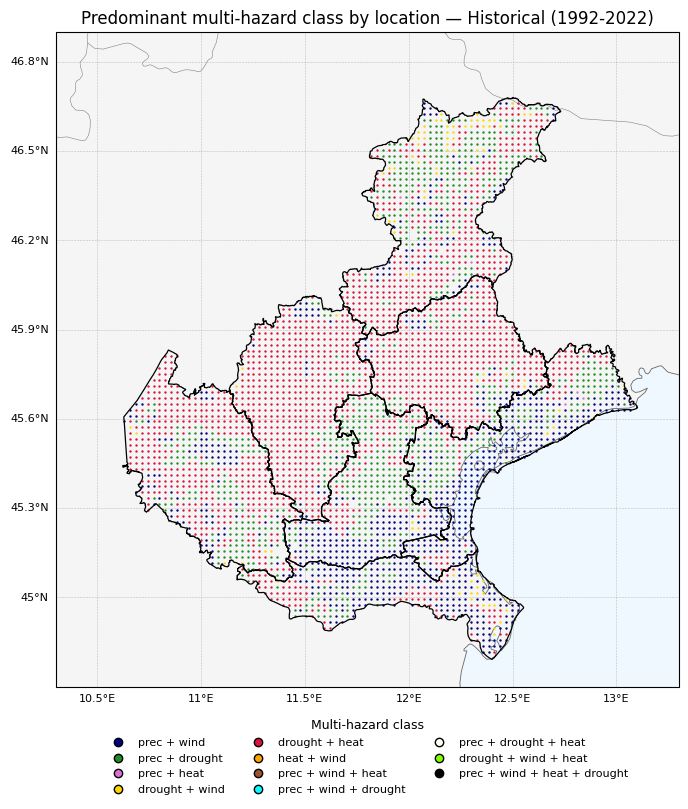

In [17]:
import pandas as pd
df=pd.read_csv('OUTPUT/flat_mh_only_events_rea.csv')
shapefile='Limiti/Regioni/c0104021_province.shp'
scenario='Historical (1992-2022)'
plot_multi_hazards_compound(
    df,
    shapefile,
    scenario,
    clip_to_veneto=True,
    outpath=None,
    extent=(10.3, 13.3, 44.7, 46.9),
)

## Landscape and seasonal plots

In [31]:
def build_pair_summaries(INPUTS: dict,
                         date_col="date", month_col="month",
                         landscape_col="landscape"):
    season_frames = []
    land_frames = []

    for pair, scen_map in INPUTS.items():
        for scen, path in scen_map.items():
            season_frames.append(
                compute_seasonality_onefile(path, scen, pair, date_col=date_col, month_col=month_col)
            )
            land_frames.append(
                compute_landscape_onefile(path, scen, pair, landscape_col=landscape_col)
            )

    seasonal_df = pd.concat(season_frames, ignore_index=True)
    landscape_df = pd.concat(land_frames, ignore_index=True)

    return seasonal_df, landscape_df

In [37]:
def month_to_season(m: int) -> str:
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Spring"
    if m in (6, 7, 8):
        return "Summer"
    return "Fall"


def compute_seasonality_onefile(csv_path: str, scenario: str, pair: str,
                                date_col="date", month_col="month") -> pd.DataFrame:
    """
    Returns tidy df: scenario, pair, season, n_days (unique dates)
    """
    df = pd.read_csv(csv_path, usecols=[date_col, month_col], low_memory=False)

    # season
    df[month_col] = pd.to_numeric(df[month_col], errors="coerce").astype("Int64")
    df = df.dropna(subset=[month_col])

    df["season"] = df[month_col].astype(int).map(month_to_season)

    # unique dates per season
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])

    out = (df.groupby("season")[date_col].nunique()
             .reindex(SEASON_ORDER).fillna(0).astype(int)
             .reset_index(name="n_days"))
    out["scenario"] = scenario
    out["pair"] = pair
    return out[["scenario", "pair", "season", "n_days"]]


def compute_landscape_onefile(csv_path: str, scenario: str, pair: str,
                              landscape_col="landscape") -> pd.DataFrame:
    """
    Returns tidy df: scenario, pair, landscape, n_rows (count rows)
    """
    df = pd.read_csv(csv_path, usecols=[landscape_col], low_memory=False)

    out = (df.groupby(landscape_col).size()
             .reindex(LANDSCAPE_ORDER).fillna(0).astype(int)
             .reset_index(name="n_rows"))
    out = out.rename(columns={landscape_col: "landscape"})
    out["scenario"] = scenario
    out["pair"] = pair
    return out[["scenario", "pair", "landscape", "n_rows"]]

def plot_seasonality_grid(seasonal_df: pd.DataFrame, pair_order=PAIR_ORDER):
    fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

    for i, pair in enumerate(pair_order):
        ax = axes[i // 3, i % 3]
        sub = seasonal_df[seasonal_df["pair"] == pair]

        pivot = (sub.pivot_table(index="scenario", columns="season", values="n_days", aggfunc="sum")
                   .reindex(SCENARIO_ORDER)
                   .reindex(columns=SEASON_ORDER)
                   .fillna(0))

        bottom = np.zeros(len(pivot.index))
        for s in SEASON_ORDER:
            ax.bar(pivot.index, pivot[s].values, bottom=bottom,
                   color=SEASON_COLORS.get(s, "grey"), label=s)
            bottom += pivot[s].values

        ax.set_title(pair.replace("_", " + "))
        ax.set_ylabel("Unique event-days")
        ax.tick_params(axis="x", rotation=0)

        if i == 0:
            ax.legend(title="Season", fontsize=8)

    fig.suptitle("Compound pair hazards — seasonal distribution", fontsize=14)
    plt.show()

def plot_landscape_grid(landscape_df: pd.DataFrame, pair_order=PAIR_ORDER, landscape_order=LANDSCAPE_ORDER):
    fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

    for i, pair in enumerate(pair_order):
        ax = axes[i // 3, i % 3]
        sub = landscape_df[landscape_df["pair"] == pair]

        pivot = (sub.pivot_table(index="scenario", columns="landscape", values="n_rows", aggfunc="sum")
                   .reindex(SCENARIO_ORDER)
                   .reindex(columns=landscape_order)
                   .fillna(0))

        bottom = np.zeros(len(pivot.index))
        for l in landscape_order:
            ax.bar(pivot.index, pivot[l].values, bottom=bottom,
                   color=LANDSCAPE_COLORS.get(l, "grey"), label=l)
            bottom += pivot[l].values

        ax.set_title(pair.replace("_", " + "))
        ax.set_ylabel("Rows (space–time cells)")
        ax.tick_params(axis="x", rotation=0)

        if i == 0:
            ax.legend(title="Landscape", fontsize=8)

    fig.suptitle("Compound pair hazards — landscape distribution", fontsize=14)
    plt.show()

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEASON_ORDER = ["Winter", "Spring", "Summer", "Fall"]
SCENARIO_ORDER = ["Historical", "RCP 4.5", "RCP 8.5"]

PAIR_ORDER = [
    "prec_wind",
    "prec_drought",
    "prec_heat",
    "drought_wind",
    "drought_heat",
    "heat_wind",
]

SEASON_COLORS = {
    "Winter": "dodgerblue",
    "Spring": "chartreuse",
    "Summer": "gold",
    "Fall": "sienna",
}

# adapt to your labels (tipo_p values) if needed
LANDSCAPE_ORDER = ["Coasts", "Plains", "Hills", "Mountains"]
LANDSCAPE_COLORS = {
    "Coasts": "aqua",
    "Plains": "olivedrab",
    "Hills": "tan",
    "Mountains": "silver",
}

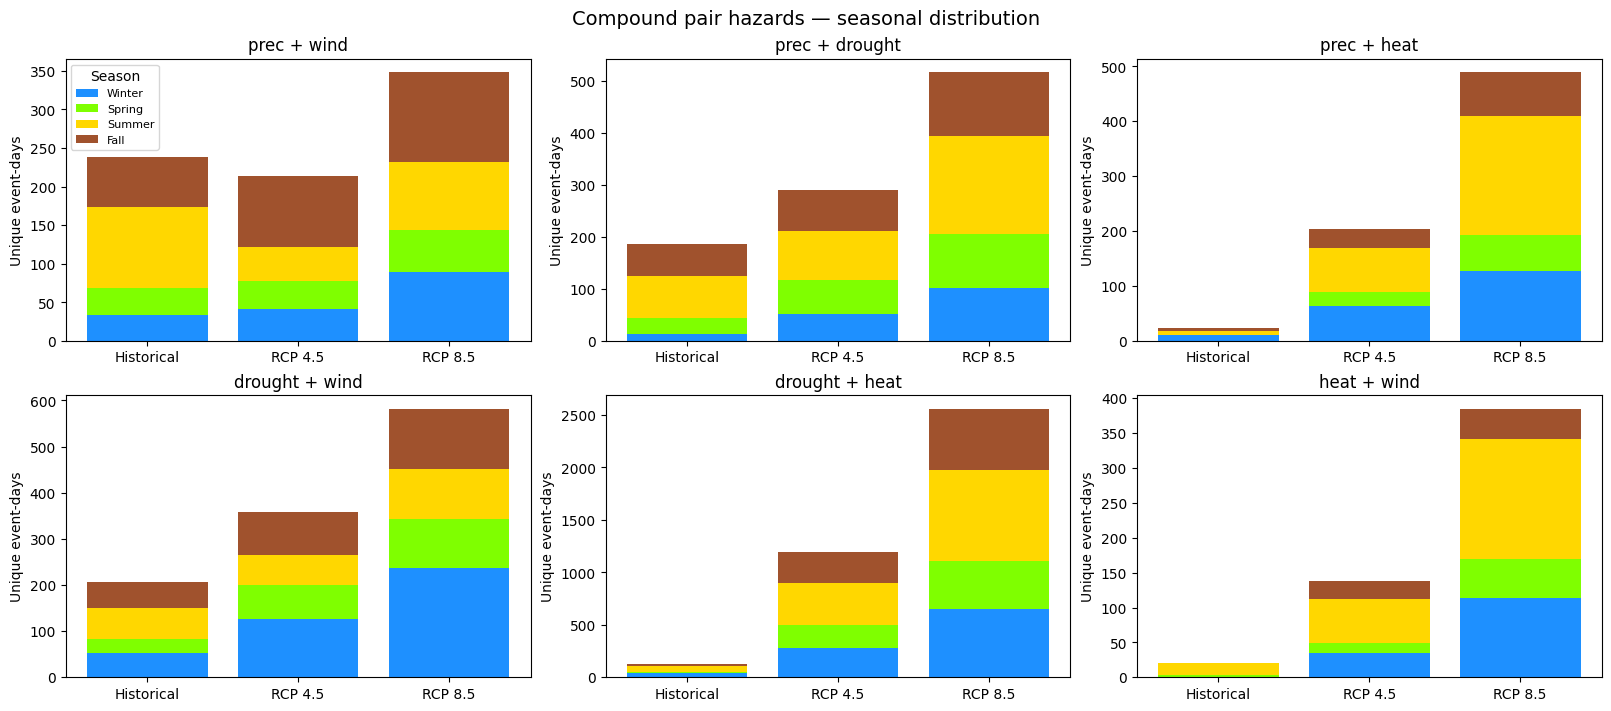

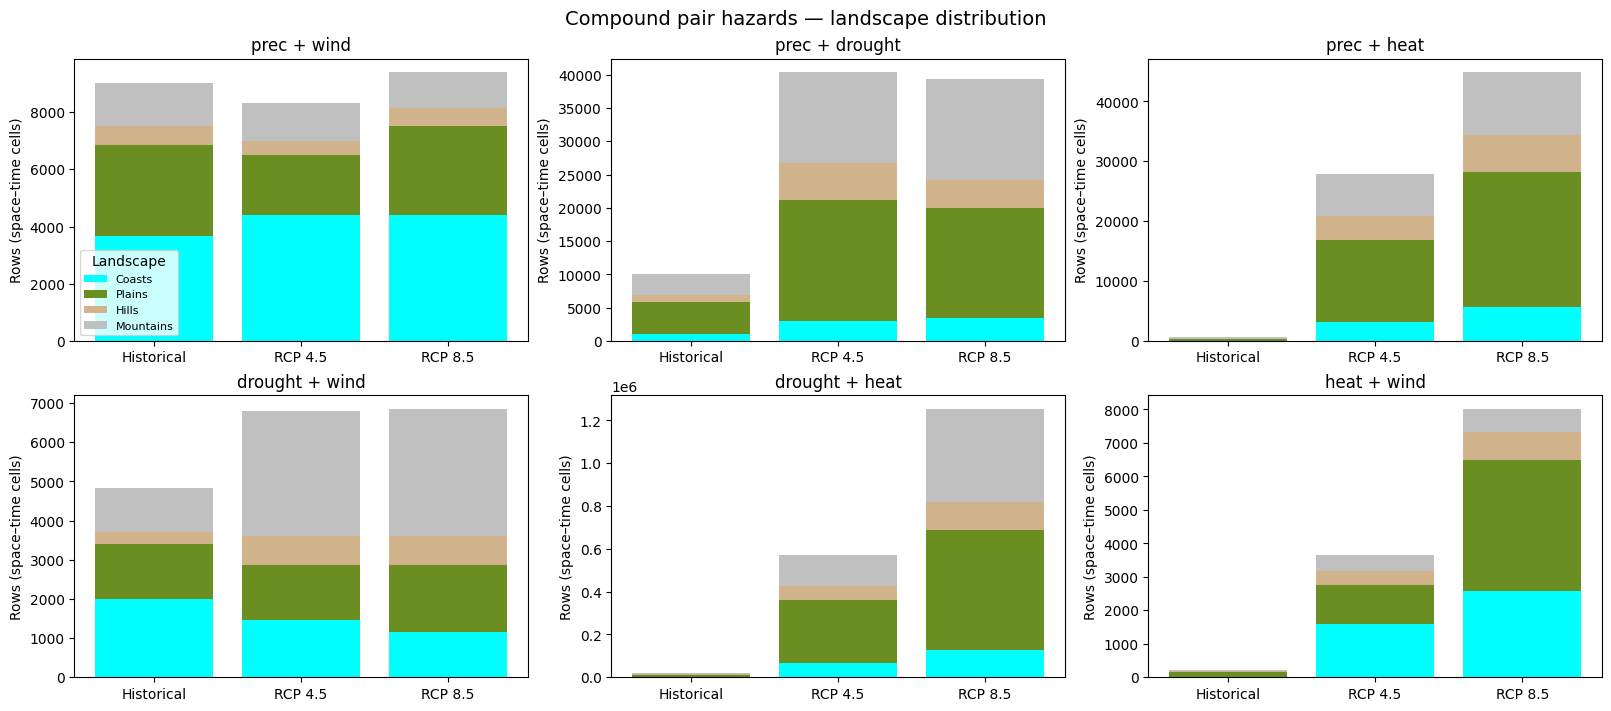

In [38]:
# Example structure (fill in your paths)
INPUTS = {
    "prec_wind": {
        "Historical": "OUTPUT/prec_wind_historical_clean.csv",
        "RCP 4.5": "OUTPUT/prec_wind_rcp_45_late_clean.csv",
        "RCP 8.5": "OUTPUT/prec_wind_rcp_85_late_clean.csv",
    },
    "prec_drought": {
        "Historical": "OUTPUT/prec_drought_historical_clean.csv",
        "RCP 4.5": "OUTPUT/prec_drought_rcp_45_late_clean.csv",
        "RCP 8.5": "OUTPUT/prec_drought_rcp_85_late_clean.csv",
    },
    "prec_heat": {
        "Historical": "OUTPUT/prec_heat_historical_clean.csv",
        "RCP 4.5": "OUTPUT/prec_heat_rcp_45_late_clean.csv",
        "RCP 8.5": "OUTPUT/prec_heat_rcp_85_late_clean.csv",
    },
    "drought_wind": {
        "Historical": "OUTPUT/drought_wind_historical_clean.csv",
        "RCP 4.5": "OUTPUT/drought_wind_rcp_45_late_clean.csv",
        "RCP 8.5": "OUTPUT/drought_wind_rcp_85_late_clean.csv",
    },
    "drought_heat": {
        "Historical": "OUTPUT/drought_heat_historical_clean.csv",
        "RCP 4.5": "OUTPUT/drought_heat_rcp_45_late_clean.csv",
        "RCP 8.5": "OUTPUT/drought_heat_rcp_85_late_clean.csv",
    },
    "heat_wind": {
        "Historical": "OUTPUT/heat_wind_historical_clean.csv",
        "RCP 4.5": "OUTPUT/heat_wind_rcp_45_late_clean.csv",
        "RCP 8.5": "OUTPUT/heat_wind_rcp_85_late_clean.csv",
    },
    # ...repeat for the other pairs
}

seasonal_df, landscape_df = build_pair_summaries(
    INPUTS,
    date_col="date",
    month_col="month",
    landscape_col="landscape"   # or "tipo_p"
)
#plot a single hazard pair
plot_seasonality_grid(seasonal_df)
plot_landscape_grid(landscape_df)

## scatter plots

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
def compute_compound_cluster_characteristics(
    df: pd.DataFrame,
    pair_cluster_col: str,      # e.g. "prec_wind"
    var1_col: str,              # e.g. "TOT_PREC"
    var2_col: str,              # e.g. "wind"
    scenario: str,
    date_col: str = "date",
) -> pd.DataFrame:
    """
    From a pixel-level compound dataset, compute per-footprint (cluster) characteristics:
    - mean var1, mean var2
    - extension = number of cells (rows)
    - duration = unique dates in cluster
    """
    needed = [pair_cluster_col, var1_col, var2_col, date_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    sub = df[df[pair_cluster_col].notna()].copy()

    # Ensure date is datetime
    sub[date_col] = pd.to_datetime(sub[date_col], errors="coerce")

    # Aggregate by compound cluster id
    out = (
        sub.groupby(pair_cluster_col)
           .agg(
               mean_var1=(var1_col, "mean"),
               mean_var2=(var2_col, "mean"),
               extension=("lon", "size"),              # number of rows/cells
               duration=(date_col, pd.Series.nunique)  # unique days
           )
           .reset_index()
           .rename(columns={pair_cluster_col: "cluster_id"})
    )

    out["scenario"] = scenario
    out["pair"] = pair_cluster_col
    out["var1"] = var1_col
    out["var2"] = var2_col

    return out

In [20]:
def build_characteristics_from_files(
    file_map: dict,  # {"Historical": path, "RCP 4.5": path, "RCP 8.5": path}
    pair_cluster_col: str,
    var1_col: str,
    var2_col: str,
) -> pd.DataFrame:
    frames = []
    for scen, path in file_map.items():
        df = pd.read_csv(path)
        frames.append(
            compute_compound_cluster_characteristics(
                df=df,
                pair_cluster_col=pair_cluster_col,
                var1_col=var1_col,
                var2_col=var2_col,
                scenario=scen
            )
        )
    return pd.concat(frames, ignore_index=True)

In [21]:
def plot_compound_scatter_by_scenario(
    characteristics_df: pd.DataFrame,
    title: str,
    x_label: str,
    y_label: str,
    scenario_colors=None,
    size_col: str = "extension",
    size_range=(50, 5000),
    global_size_min=None,
    global_size_max=None,
    invert_x=False,
    sqrt_scaling=True
):
    if scenario_colors is None:
        scenario_colors = {
            "Historical": "blue",
            "RCP 4.5": "green",
            "RCP 8.5": "red",
        }

    df = characteristics_df.copy()

    # --- Global / local scaling bounds
    vmin = global_size_min if global_size_min is not None else df[size_col].min()
    vmax = global_size_max if global_size_max is not None else df[size_col].max()

    smin, smax = size_range

    # --- Robust size scaling (sqrt)
    if vmax == vmin:
        df["plot_size"] = (smin + smax) / 2
    elif sqrt_scaling:
        df["plot_size"] = (
            (np.sqrt(df[size_col]) - np.sqrt(vmin))
            / (np.sqrt(vmax) - np.sqrt(vmin))
            * (smax - smin)
            + smin
        )
    else:
        df["plot_size"] = (
            (np.log(df[size_col]+3) - np.log(vmin+3))
            / (np.log(vmax+3) - np.log(vmin+3))
            * (smax - smin)
            + smin
        )

    plt.figure(figsize=(12, 8))

    for scen, grp in df.groupby("scenario"):
        plt.scatter(
            grp["mean_var1"],
            grp["mean_var2"],
            s=grp["plot_size"],
            alpha=0.65,
            edgecolor="k",
            linewidth=0.3,
            color=scenario_colors.get(scen, "gray"),
            label=scen,
        )

    if invert_x:
        plt.gca().invert_xaxis()

    plt.title(title, fontsize=20)
    plt.xlabel(x_label, fontsize=17)
    plt.ylabel(y_label, fontsize=17)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Scenario", loc="upper right", fontsize=17)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3373706/2569625252.py:9: DtypeWarning: Columns (21,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


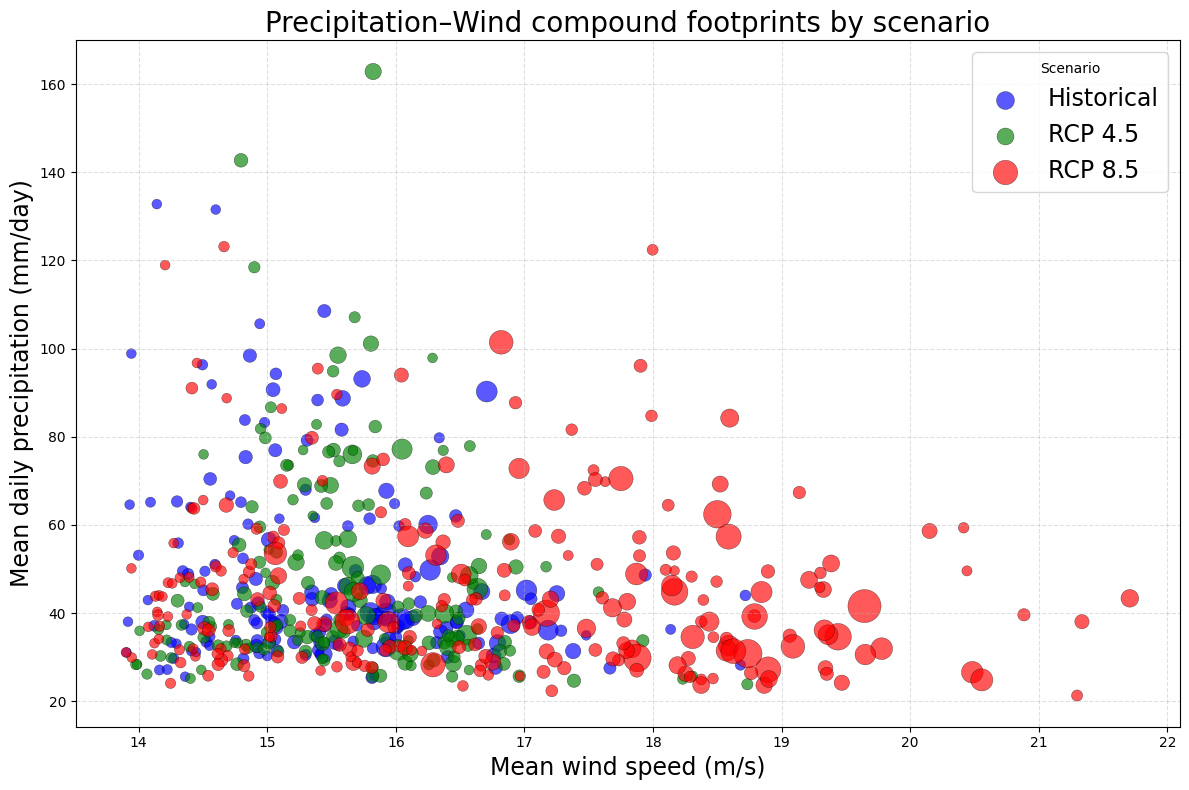

In [23]:
#global_min = all_characteristics_df["extension"].min()
#global_max = all_characteristics_df["extension"].max()
global_min = 1 #These values have been calculated before across all the MHs
global_max = 320251
files_prec_wind = {
    "Historical": "OUTPUT/prec_wind_historical_clean.csv",
    "RCP 4.5": "OUTPUT/prec_wind_rcp_45_late_clean.csv",
    "RCP 8.5": "OUTPUT/prec_wind_rcp_85_late_clean.csv",
}

char_df1 = build_characteristics_from_files(
    file_map=files_prec_wind,
    pair_cluster_col="prec_wind",
    var2_col="TOT_PREC",
    var1_col="wind",
)

plot_compound_scatter_by_scenario(
    char_df1,
    title="Precipitation–Wind compound footprints by scenario",
    y_label="Mean daily precipitation (mm/day)",
    x_label="Mean wind speed (m/s)",
    global_size_min=global_min,
    global_size_max=global_max
)

/tmp/ipykernel_3373706/2569625252.py:9: DtypeWarning: Columns (7,10,17,18,19,20,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/tmp/ipykernel_3373706/2569625252.py:9: DtypeWarning: Columns (7,10,17,18,19,20,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


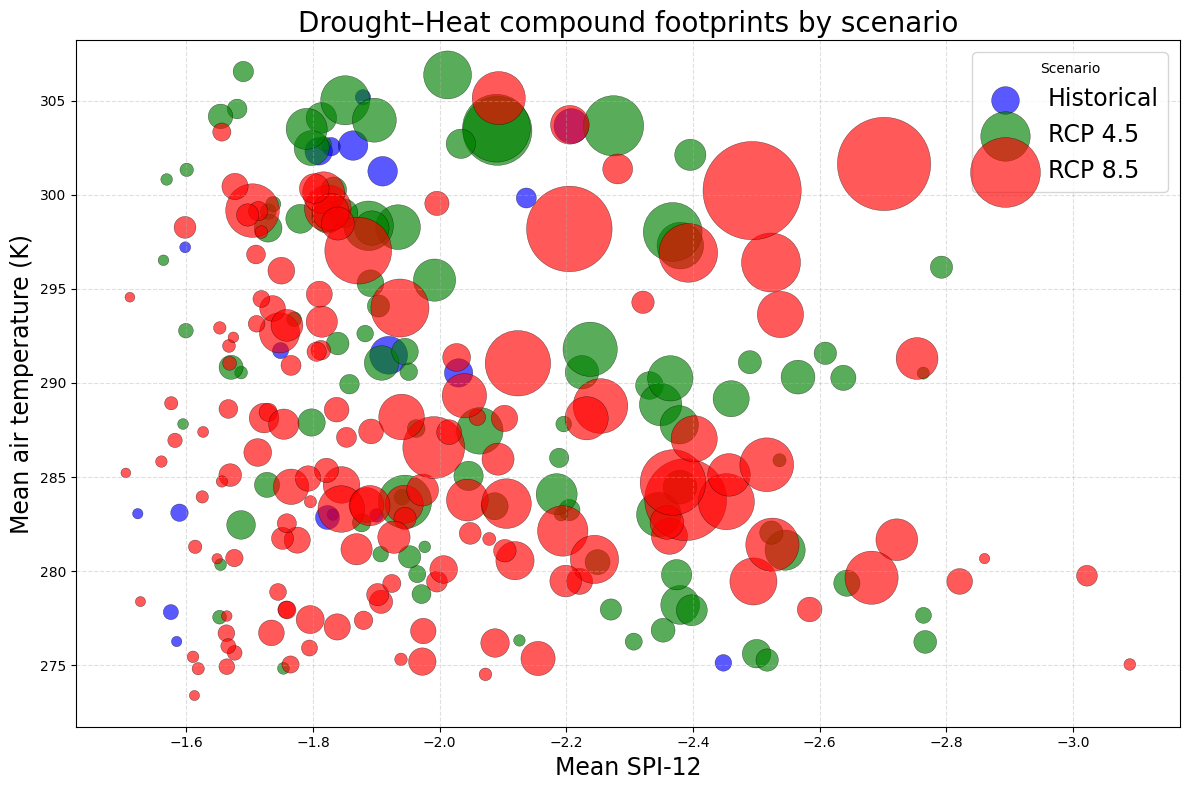

In [25]:
files_prec_wind = {
    "Historical": "OUTPUT/drought_heat_historical_clean.csv",
    "RCP 4.5": "OUTPUT/drought_heat_rcp_45_late_clean.csv",
    "RCP 8.5": "OUTPUT/drought_heat_rcp_85_late_clean.csv",
}

char_df2 = build_characteristics_from_files(
    file_map=files_prec_wind,
    pair_cluster_col="drought_heat",
    var1_col="spi_pearson_360",
    var2_col="T_2M",
)

plot_compound_scatter_by_scenario(
    char_df2,
    title="Drought–Heat compound footprints by scenario",
    x_label="Mean SPI-12",
    y_label="Mean air temperature (K)",
    global_size_min=global_min,
    global_size_max=global_max,
    invert_x=True
)

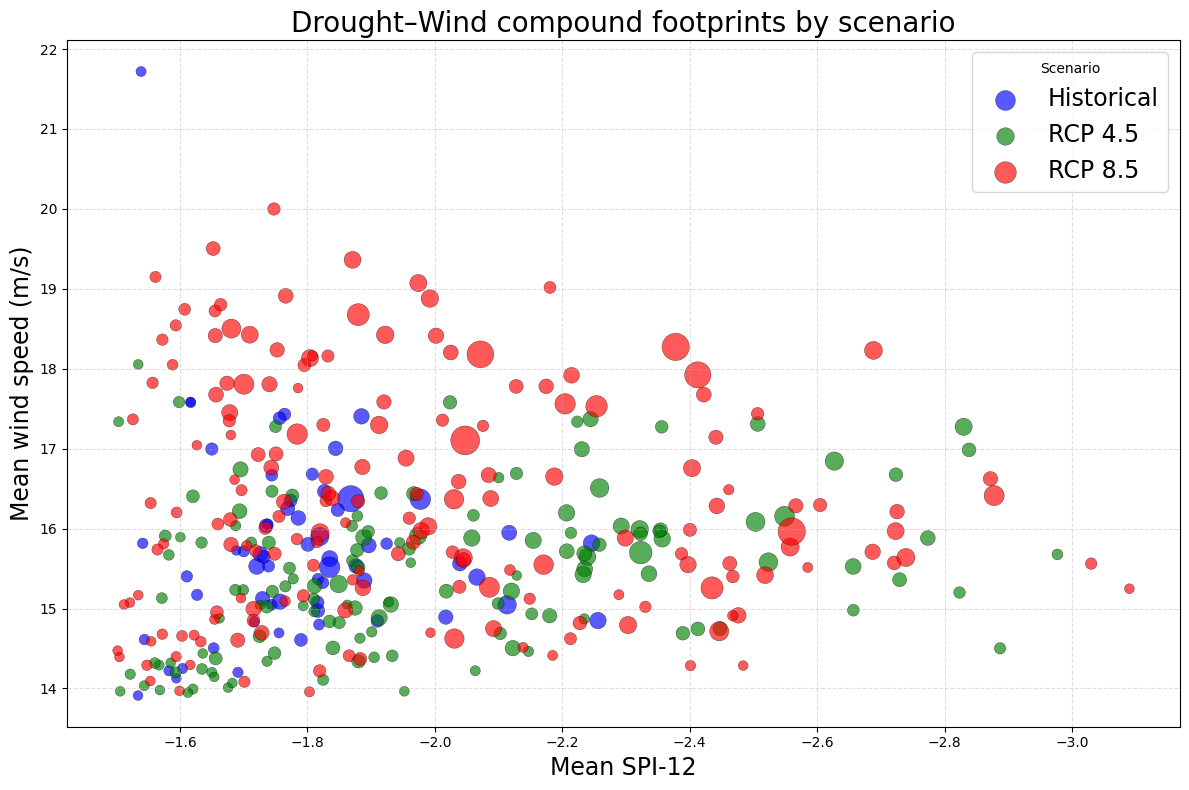

In [26]:
files_prec_wind = {
    "Historical": "OUTPUT/drought_wind_historical_clean.csv",
    "RCP 4.5": "OUTPUT/drought_wind_rcp_45_late_clean.csv",
    "RCP 8.5": "OUTPUT/drought_wind_rcp_85_late_clean.csv",
}

char_df3 = build_characteristics_from_files(
    file_map=files_prec_wind,
    pair_cluster_col="drought_wind",
    var1_col="spi_pearson_360",
    var2_col="wind",
)

plot_compound_scatter_by_scenario(
    char_df3,
    title="Drought–Wind compound footprints by scenario",
    x_label="Mean SPI-12",
    y_label="Mean wind speed (m/s)",
    global_size_min=global_min,
    global_size_max=global_max,
    invert_x=True
)

/tmp/ipykernel_3373706/2569625252.py:9: DtypeWarning: Columns (10,13,17,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


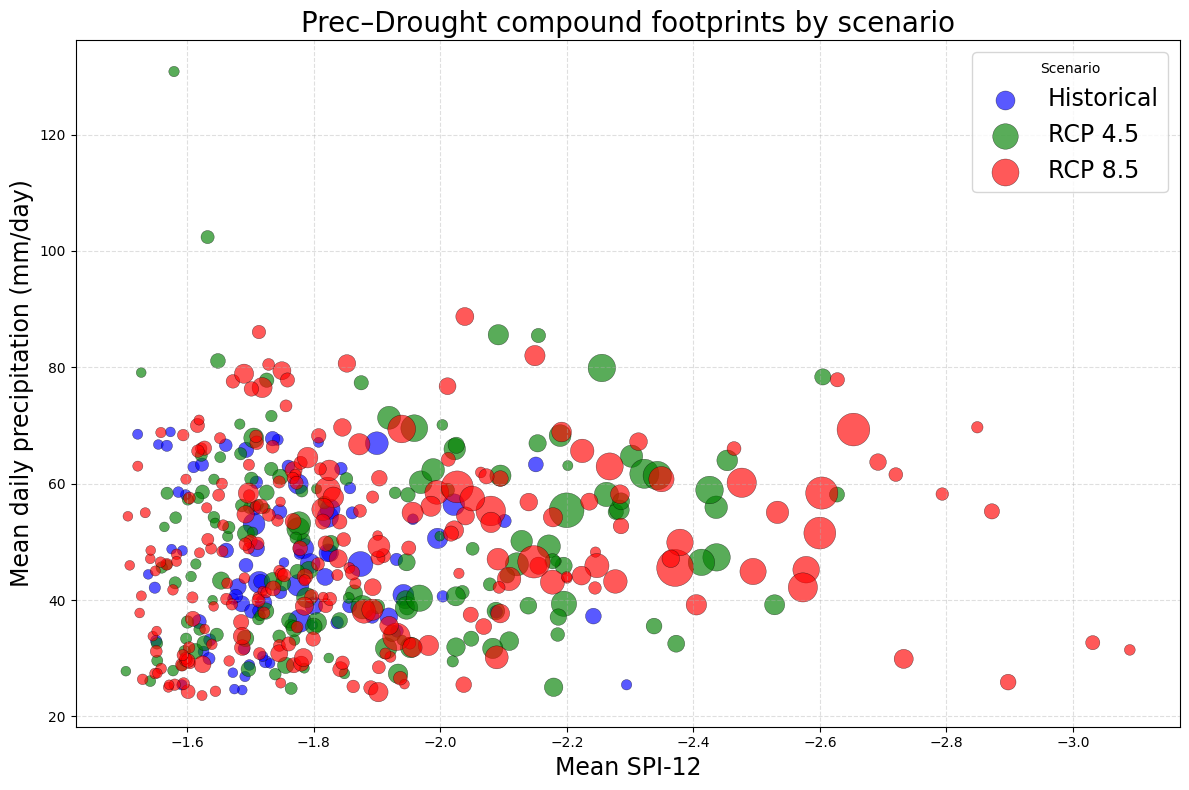

In [27]:
files_prec_wind = {
    "Historical": "OUTPUT/prec_drought_historical_clean.csv",
    "RCP 4.5": "OUTPUT/prec_drought_rcp_45_late_clean.csv",
    "RCP 8.5": "OUTPUT/prec_drought_rcp_85_late_clean.csv",
}

char_df4 = build_characteristics_from_files(
    file_map=files_prec_wind,
    pair_cluster_col="prec_drought",
    var1_col="spi_pearson_360",
    var2_col="TOT_PREC",
)

plot_compound_scatter_by_scenario(
    char_df4,
    title="Prec–Drought compound footprints by scenario",
    x_label="Mean SPI-12",
    y_label="Mean daily precipitation (mm/day)",
    global_size_min=global_min,
    global_size_max=global_max,
    invert_x=True
)

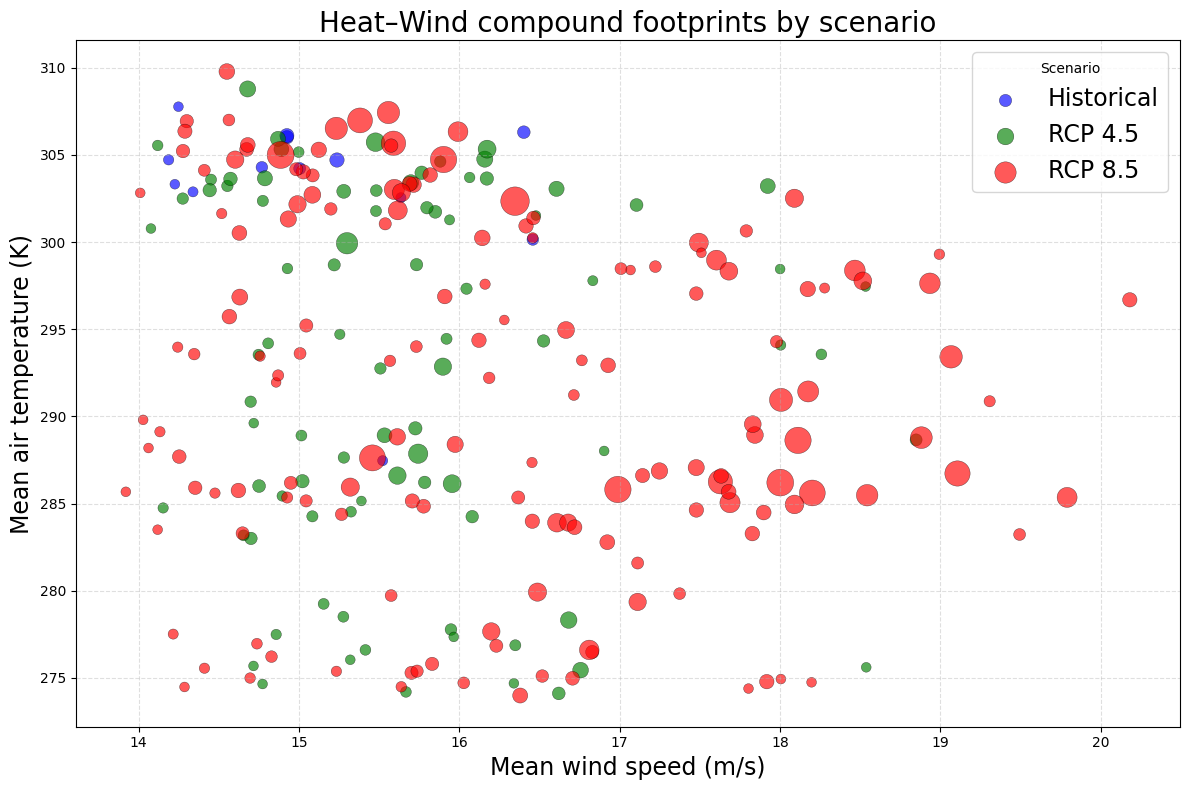

In [28]:
files_prec_wind = {
    "Historical": "OUTPUT/heat_wind_historical_clean.csv",
    "RCP 4.5": "OUTPUT/heat_wind_rcp_45_late_clean.csv",
    "RCP 8.5": "OUTPUT/heat_wind_rcp_85_late_clean.csv",
}

char_df5 = build_characteristics_from_files(
    file_map=files_prec_wind,
    pair_cluster_col="heat_wind",
    var1_col="wind",
    var2_col="T_2M",
)

plot_compound_scatter_by_scenario(
    char_df5,
    title="Heat–Wind compound footprints by scenario",
    x_label="Mean wind speed (m/s)",
    y_label="Mean air temperature (K)",
    global_size_min=global_min,
    global_size_max=global_max,
    invert_x=False
)

/tmp/ipykernel_3373706/2569625252.py:9: DtypeWarning: Columns (20,24,25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


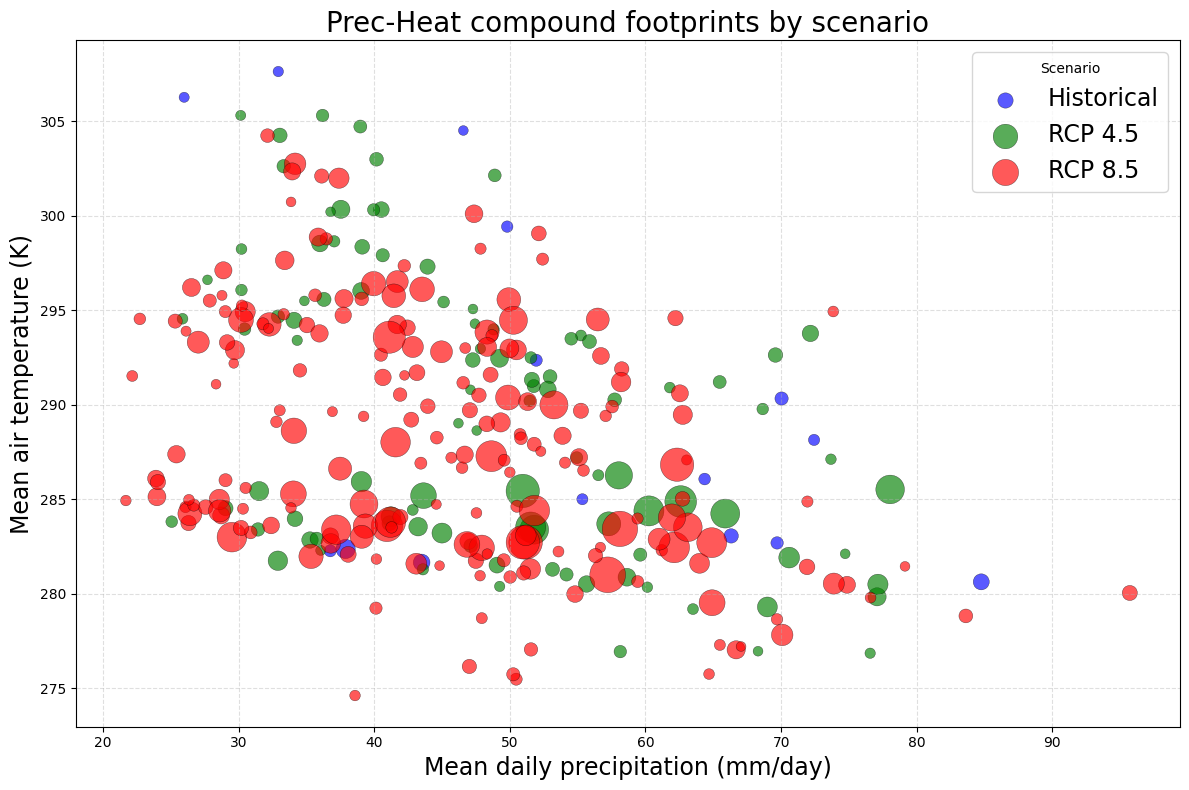

In [29]:
files_prec_wind = {
    "Historical": "OUTPUT/prec_heat_historical_clean.csv",
    "RCP 4.5": "OUTPUT/prec_heat_rcp_45_late_clean.csv",
    "RCP 8.5": "OUTPUT/prec_heat_rcp_85_late_clean.csv",
}

char_df6 = build_characteristics_from_files(
    file_map=files_prec_wind,
    pair_cluster_col="prec_heat",
    var1_col="TOT_PREC",
    var2_col="T_2M",
)

plot_compound_scatter_by_scenario(
    char_df6,
    title="Prec-Heat compound footprints by scenario",
    x_label="Mean daily precipitation (mm/day)",
    y_label="Mean air temperature (K)",
    global_size_min=global_min,
    global_size_max=global_max,
    invert_x=False
)